<a href="https://colab.research.google.com/github/SlepenkovaDaria/My-homework/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Загрузка и первый взгляд на данные

In [199]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

path = kagglehub.dataset_download("tunguz/online-retail-ii")
df = pd.read_csv(os.path.join(path, "online_retail_II.csv"), encoding = "latin-1")

Using Colab cache for faster access to the 'online-retail-ii' dataset.


In [200]:
print(f"Table size: {df.shape}\n")

Table size: (541910, 8)



In [201]:
print("First rows of the table:")
df.head(10)

First rows of the table:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom
9,536368,22960,JAM MAKING SET WITH JARS,6,12/1/10 8:34,4.25,13047.0,United Kingdom


In [202]:
print("Column types:")
df.info()

Column types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [203]:
print("Basic statistics:")
df.describe()

Basic statistics:


,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [204]:
print("Number of passes:")
df.isna().sum()

Number of passes:


,0
Invoice,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
Price,0
Customer ID,135080
Country,0


Основные выводы:

1.   Датасет имеет 541910 строк и 8 столбцов: Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country.

2.   Пропуски присутствуют в столбцах Description и Customer ID.
Для анализа покупателей создадим датасет df_customers, удалив строки без Customer ID, поскольку без идентификатора невозможно анализировать поведение конкретного клиента. Пропуски в Description заменим на "Unknown".
Для анализа товаров и продаж создадим датасет df_sales, сохранив все строки, включая покупки без Customer ID, поскольку они содержат информацию о товарах и выручке. Пропуски в Description также заменим на "Unknown".

3. Столбец InvoiceDate имеет тип object. Для дальнейшей работы преобразуем данные в этом столбце.

4. В данных присутствуют возвраты и отмененные заказы, что видно по отрицательным значениям Quantity и Price. Для дальнейшего анализа продаж потребуется отделить реальные покупки от отмен.

5. Максимальные значения Quantity и Price значительно превышают средние значения и могут являться либо выбросами, либо очень крупными заказами. Их необходимо дополнительно исследовать отдельно.

# Подготовка и анализ df_sales

In [205]:
df_sales = df.copy()
df_sales["Description"] = df_sales["Description"].fillna("Unknown")

df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"], format = "%m/%d/%y %H:%M")

print(f"Duplicates: {df_sales.duplicated().sum()}")
print(f"Negative quantity: {(df_sales["Quantity"] <= 0).sum()}")
print(f"Non-positive price: {(df_sales["Price"] <= 0).sum()}")
print(f"Cancelled invoices: {df_sales["Invoice"].astype(str).str.startswith("C").sum()}")

df_sales_clean = df_sales.drop_duplicates().copy()

df_sales_clean = df_sales_clean[
    (df_sales_clean["Quantity"] > 0) &
    (df_sales_clean["Price"] > 0) &
    (~df_sales_clean["Invoice"].astype(str).str.startswith("C"))
].copy()

df_sales_clean["Revenue"] = (df_sales_clean["Quantity"] * df_sales_clean["Price"])

print(f"Clean sales table size: {df_sales_clean.shape}")

Duplicates: 5268
Negative quantity: 10624
Non-positive price: 2517
Cancelled invoices: 9288
Clean sales table size: (524879, 9)


In [206]:
high_quantity = df_sales_clean["Quantity"] > 1000
high_price = df_sales_clean["Price"] > 500

print("Rows with Quantity > 1000:", high_quantity.sum())
print("Rows with Price > 500:", high_price.sum())

Rows with Quantity > 1000: 106
Rows with Price > 500: 151


In [207]:
print(df_sales_clean[["Invoice", "StockCode", "Description", "Quantity", "Price", "Country"]]
    .sort_values("Quantity", ascending = False)
    .head(106)
    .to_string(index = False))

print(df_sales_clean[["Invoice", "StockCode", "Description", "Quantity", "Price", "Country"]]
    .sort_values("Price", ascending = False)
    .head(151)
    .to_string(index = False))

Invoice StockCode                         Description  Quantity  Price        Country
 581483     23843         PAPER CRAFT , LITTLE BIRDIE     80995   2.08 United Kingdom
 541431     23166      MEDIUM CERAMIC TOP STORAGE JAR     74215   1.04 United Kingdom
 573008     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   0.21 United Kingdom
 554868     22197                SMALL POPCORN HOLDER      4300   0.72 United Kingdom
 544612     22053               EMPIRE DESIGN ROSETTE      3906   0.82 United Kingdom
 560599     18007 ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   0.06 United Kingdom
 550461     21108  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   2.10 United Kingdom
 540815     21108  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   2.10 United Kingdom
 573995     16014         SMALL CHINESE STYLE SCISSOR      3000   0.32 United Kingdom
 536830     84077   WORLD WAR 2 GLIDERS ASSTD DESIGNS      2880   0.18 United Kingdom
 562439     84879       ASSORTED COLOUR BIRD ORNAMENT 

Заказы на 80995 и 74215 штук выглядят очень странно, отнесем их к выбросам и удалим из таблицы. Остальные заказы с большим количеством можно отнести к оптовым заказам, такие значения вполне возможны.

Экстремальные значения Price относятся в основном к сервисным и бухгалтерским строкам (а именно: AMAZON FEE, ADJUST BAD DEBT, POSTAGE, DOTCOM POSTAGE, MANUAL), поэтому исключим их из дальнейшего анализа товаров. Строка с товаром "PICNIC BASKET WICKER 60 PIECES" повторяется два раза, но с разным количеством - вероятно, это ошибочная строка, удалим.

Quantity 0.95 quantile: 30.0
Price 0.95 quantile: 9.95
Revenue 0.95 quantile: 59.4


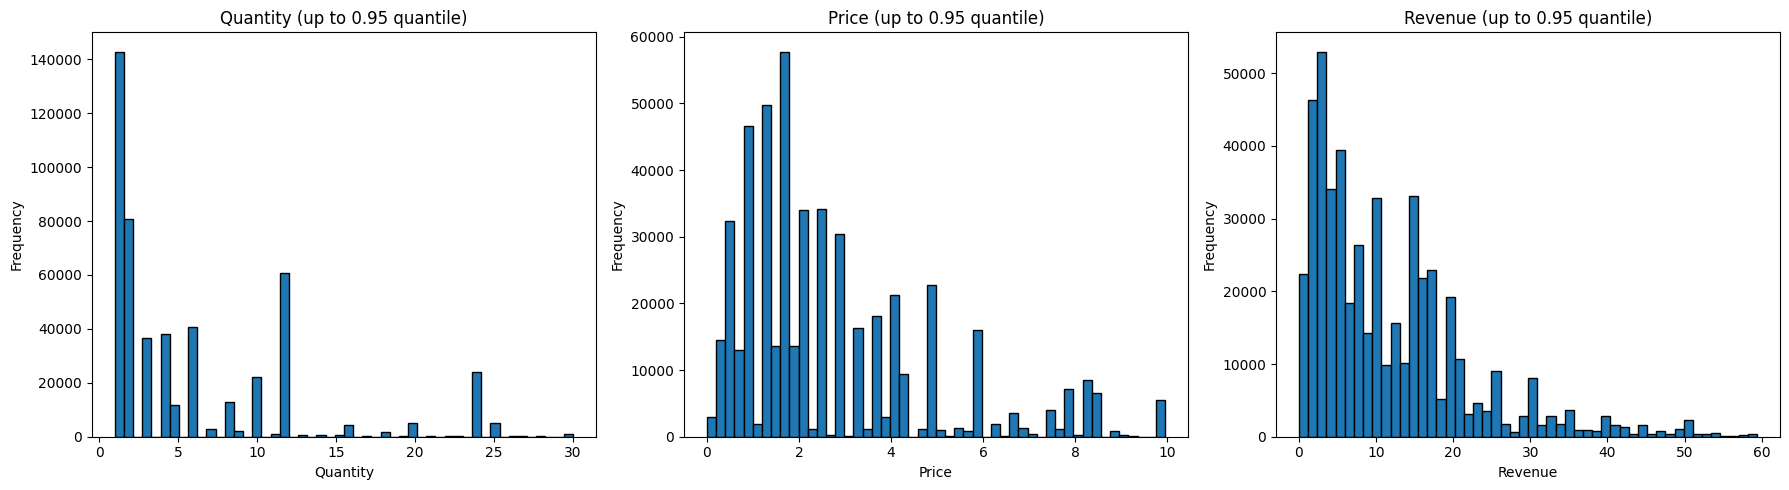

In [208]:
df_sales_clean["Description"] = (df_sales_clean["Description"].str.strip().str.upper())
df_sales_clean = df_sales_clean[~df_sales_clean["Quantity"].isin([80995, 74215])].copy()

excluded = [
    "MANUAL",
    "POSTAGE",
    "DOTCOM POSTAGE",
    "AMAZON FEE",
    "ADJUST BAD DEBT",
    "PICNIC BASKET WICKER 60 PIECES"
]

products_only = df_sales_clean[~df_sales_clean["Description"].isin(excluded)].copy()

q_quantity = products_only["Quantity"].quantile(0.95)
q_price = products_only["Price"].quantile(0.95)
q_revenue = products_only["Revenue"].quantile(0.95)

print(f"Quantity 0.95 quantile: {q_quantity}")
print(f"Price 0.95 quantile: {q_price}")
print(f"Revenue 0.95 quantile: {q_revenue}")

fig, axes = plt.subplots(1, 3, figsize = (18, 5))

axes[0].hist(products_only[products_only["Quantity"] <= q_quantity]["Quantity"], bins = 50, edgecolor = "black")
axes[0].set_title("Quantity (up to 0.95 quantile)")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

axes[1].hist(products_only[products_only["Price"] <= q_price]["Price"], bins = 50, edgecolor = "black")
axes[1].set_title("Price (up to 0.95 quantile)")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Frequency")

axes[2].hist(products_only[products_only["Revenue"] <= q_revenue]["Revenue"], bins = 50, edgecolor = "black")
axes[2].set_title("Revenue (up to 0.95 quantile)")
axes[2].set_xlabel("Revenue")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [209]:
products_only.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,522722.000000,522722,522722.000000,391294.000000,522722.000000
mean,10.342601,2011-07-04 16:44:08.195216384,3.285503,15294.923671,19.073067
min,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13969.000000,3.900000
50%,4.000000,2011-07-20 11:55:00,2.080000,15157.000000,9.900000
75%,12.000000,2011-10-19 11:44:00,4.130000,16794.000000,17.700000
max,4800.000000,2011-12-09 12:50:00,295.000000,18287.000000,7144.720000
std,37.847668,NaN,4.282464,1710.133020,65.292442


*  У 95% строк количество товара не превышает 30
*  У 95% строк цена не превышает 9.95
*  У 95% строк выручка не превышает 59.4

Выводы:

1. Большинство покупок содержит небольшое количество товаров. Чаще всего покупают 1-5 единиц товара, реже - 10-12. Покупки более чем на 20-30 единиц встречаются редко. Видны пики в точках 12 и 24. Это похоже на покупку товаров упаковками или наборами по 12 и 24 штуки.

2. Цены товаров в основном невысокие. Большинство товаров стоит от 1 до 5 денежных единиц.

3. Выручка по одной строке заказа обычно невелика. Для большинства позиций она составляет менее 20 денежных единиц, а значения выше 40–60 встречаются редко.

Все три распределения имеют асимметрию: большинство наблюдений сосредоточено около малых значений, а крупные покупки и дорогие товары встречаются редко.

# Подготовка и анализ df_customers

In [210]:
df_customers = products_only.dropna(subset = ["Customer ID"]).copy()
df_customers["Customer ID"] = df_customers["Customer ID"].astype(int)

print(f"Table size: {df_customers.shape}\n")
df_customers.info()

Table size: (391294, 9)

<class 'pandas.core.frame.DataFrame'>
Index: 391294 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      391294 non-null  object        
 1   StockCode    391294 non-null  object        
 2   Description  391294 non-null  object        
 3   Quantity     391294 non-null  int64         
 4   InvoiceDate  391294 non-null  datetime64[ns]
 5   Price        391294 non-null  float64       
 6   Customer ID  391294 non-null  int64         
 7   Country      391294 non-null  object        
 8   Revenue      391294 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 29.9+ MB


Пропуски отсутствуют, все дубли/выбросы/неверные значения очищены ранее.

In [211]:
print(f"Min date: {df_customers["InvoiceDate"].min()}")
print(f"Max date: {df_customers["InvoiceDate"].max()}")

snapshot_date = df_customers["InvoiceDate"].max() - pd.Timedelta(days = 60)
print(f"Snapshot_date: {snapshot_date}")

Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00
Snapshot_date: 2011-10-10 12:50:00


In [213]:
history = df_customers[df_customers["InvoiceDate"] < snapshot_date].copy()

customer_features = history.groupby("Customer ID").agg(
    last_purchase_date = ("InvoiceDate", "max"),
    Frequency = ("Invoice", "nunique"),
    Monetary = ("Revenue", "sum")).reset_index()

customer_features["Recency"] = (snapshot_date - customer_features["last_purchase_date"]).dt.days

customer_features = customer_features.drop(columns = "last_purchase_date")

In [214]:
print(f"Table size: {customer_features.shape}\n")

Table size: (3728, 4)



In [215]:
print("First rows of the table:")
customer_features.head(10)

First rows of the table:


,Customer ID,Frequency,Monetary,Recency
0,12347,5,2790.86,69
1,12348,4,1437.24,14
2,12350,1,294.40,249
3,12352,6,1154.01,11
4,12353,1,89.00,143
5,12354,1,1079.40,171
6,12355,1,459.40,153
7,12356,2,2429.08,185
8,12358,1,404.86,90
9,12359,3,3495.73,129


In [216]:
print("Column types:")
customer_features.info()

Column types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3728 entries, 0 to 3727
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  3728 non-null   int64  
 1   Frequency    3728 non-null   int64  
 2   Monetary     3728 non-null   float64
 3   Recency      3728 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 116.6 KB


In [217]:
print("Basic statistics:")
customer_features.describe()

Basic statistics:


,Customer ID,Frequency,Monetary,Recency
count,3728.000000,3728.000000,3728.000000,3728.000000
mean,15276.321620,3.656384,1689.271541,92.894045
std,1720.145333,6.232178,7114.195370,88.929089
min,12347.000000,1.000000,2.900000,0.000000
25%,13779.500000,1.000000,284.277500,18.000000
50%,15253.500000,2.000000,593.790000,60.000000
75%,16754.250000,4.000000,1424.170000,151.000000
max,18287.000000,144.000000,203146.860000,313.000000


Максимальные значения в столбцах Frequency и Monetary могут говорить о выбросах. Однако, у нас совсем немного клиентов - 3728. Не будем удалять, а применим логарифмирование признаков.

In [218]:
customer_features["Recency_log"] = np.log1p(customer_features["Recency"])
customer_features["Frequency_log"] = np.log1p(customer_features["Frequency"])
customer_features["Monetary_log"] = np.log1p(customer_features["Monetary"])

customer_features = customer_features.drop(columns = ["Recency", "Frequency", "Monetary"])

In [219]:
customer_features.head(10)

,Customer ID,Recency_log,Frequency_log,Monetary_log
0,12347,4.248495,1.791759,7.934463
1,12348,2.708050,1.609438,7.271175
2,12350,5.521461,0.693147,5.688330
3,12352,2.484907,1.945910,7.051864
4,12353,4.969813,0.693147,4.499810
5,12354,5.147494,0.693147,6.985087
6,12355,5.036953,0.693147,6.132096
7,12356,5.225747,1.098612,7.795679
8,12358,4.510860,0.693147,6.006008
9,12359,4.867534,1.386294,8.159584


In [220]:
customer_features.describe()

,Customer ID,Recency_log,Frequency_log,Monetary_log
count,3728.000000,3728.000000,3728.000000,3728.000000
mean,15276.321620,3.892557,1.253960,6.459290
std,1720.145333,1.337591,0.641445,1.219731
min,12347.000000,0.000000,0.693147,1.360977
25%,13779.500000,2.944439,0.693147,5.653462
50%,15253.500000,4.110874,1.098612,6.388208
75%,16754.250000,5.023881,1.609438,7.262046
max,18287.000000,5.749393,4.976734,12.221689


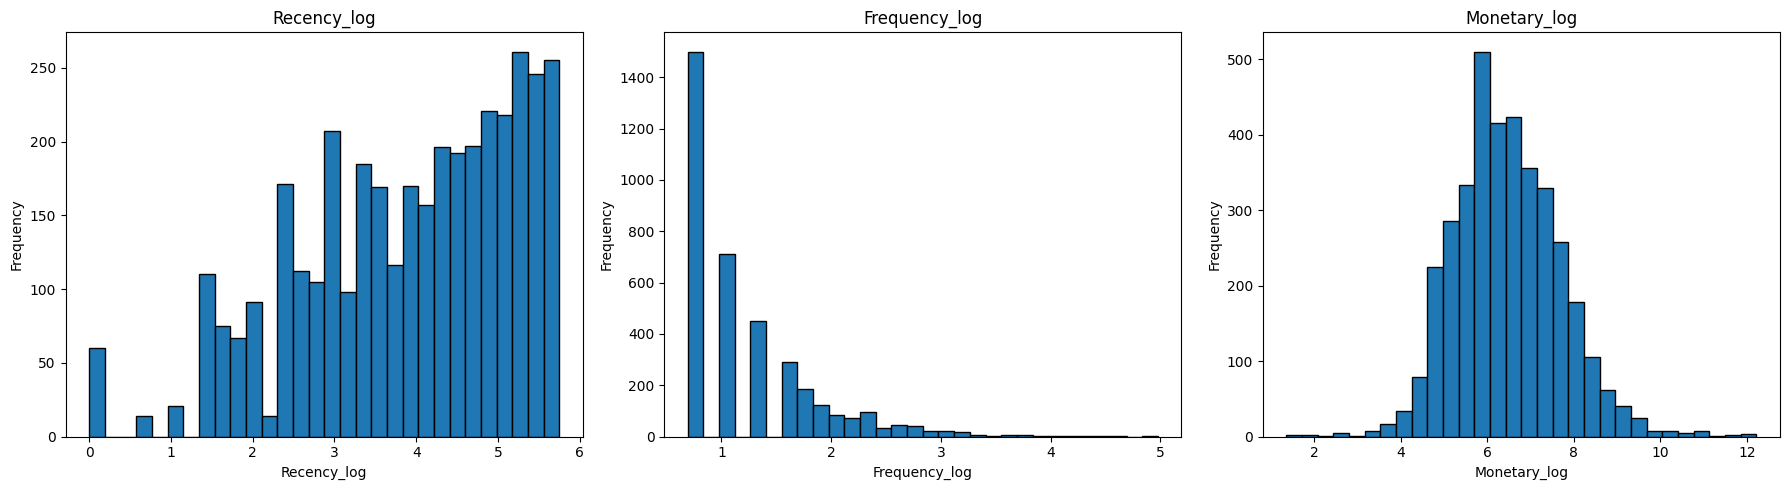

In [221]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

axes[0].hist(customer_features["Recency_log"], bins = 30, edgecolor = "black")
axes[0].set_title("Recency_log")
axes[0].set_xlabel("Recency_log")
axes[0].set_ylabel("Frequency")

axes[1].hist(customer_features["Frequency_log"], bins = 30, edgecolor = "black")
axes[1].set_title("Frequency_log")
axes[1].set_xlabel("Frequency_log")
axes[1].set_ylabel("Frequency")

axes[2].hist(customer_features["Monetary_log"], bins = 30, edgecolor = "black")
axes[2].set_title("Monetary_log")
axes[2].set_xlabel("Monetary_log")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Выводы:

1.   Большинство клиентов имеют большие значения Recency_log, то есть давно не совершали покупок к моменту 10.10.2011. Это означает, что в базе много давно неактивных клиентов.

2.    У большинства клиентов очень мало покупок, а небольшая группа клиентов покупает заметно чаще. Это выглядит нормально: есть много разовых покупателей и мало постоянных.

3. Monetary_log после логарифмирования стал близок к нормальному распределению.

In [222]:
future = df_customers[df_customers["InvoiceDate"] >= snapshot_date].copy()

returned_customers = future["Customer ID"].unique()

customer_features["Returned"] = (customer_features["Customer ID"].isin(returned_customers))

print(customer_features["Returned"].value_counts())

customer_features.head(10)

Returned
False    1940
True     1788
Name: count, dtype: int64


,Customer ID,Recency_log,Frequency_log,Monetary_log,Returned
0,12347,4.248495,1.791759,7.934463,True
1,12348,2.708050,1.609438,7.271175,False
2,12350,5.521461,0.693147,5.688330,False
3,12352,2.484907,1.945910,7.051864,True
4,12353,4.969813,0.693147,4.499810,False
5,12354,5.147494,0.693147,6.985087,False
6,12355,5.036953,0.693147,6.132096,False
7,12356,5.225747,1.098612,7.795679,True
8,12358,4.510860,0.693147,6.006008,True
9,12359,4.867534,1.386294,8.159584,True


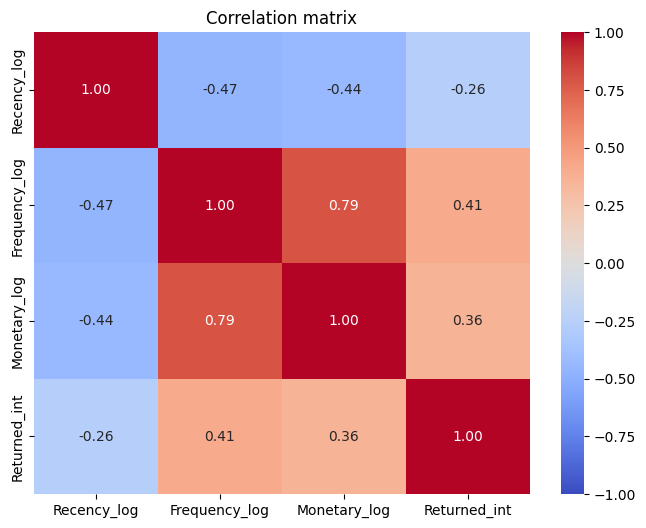

In [223]:
customer_features["Returned_int"] = customer_features["Returned"].astype(int)

corr_matrix = customer_features[["Recency_log", "Frequency_log", "Monetary_log", "Returned_int"]].corr()

plt.figure(figsize = (8, 6))

sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1)

plt.title("Correlation matrix")
plt.show()

Выводы:

1. Наиболее сильная связь с возвратом клиента наблюдается у Frequency_log. Чем чаще клиент покупал в прошлом, тем выше вероятность, что он вернётся.

2. Monetary_log тоже связан с возвратом: клиенты, которые тратили больше денег, чаще возвращаются.

3. Recency_log имеет отрицательную корреляцию с целевой переменной. Чем больше времени прошло с последней покупки, тем ниже вероятность, что клиент снова совершит покупку.

4. Между Frequency_log и Monetary_log довольно высокая корреляция. Это означает, что клиенты, которые покупают чаще, обычно тратят и больше.

5. Recency_log отрицательно связан и с Frequency_log, и с Monetary_log. То есть более активные и более ценные клиенты, как правило, покупали недавно.